In [1]:
! pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing 

# First Applying some EDA

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from skimage.io import imread

image_dir =  "/kaggle/input/cloud-masking-dataset/content/train/data" 
mask_dir  = "/kaggle/input/cloud-masking-dataset/content/train/masks" 


## Getting the Coverage of the images
### i.e: how are the images distributed

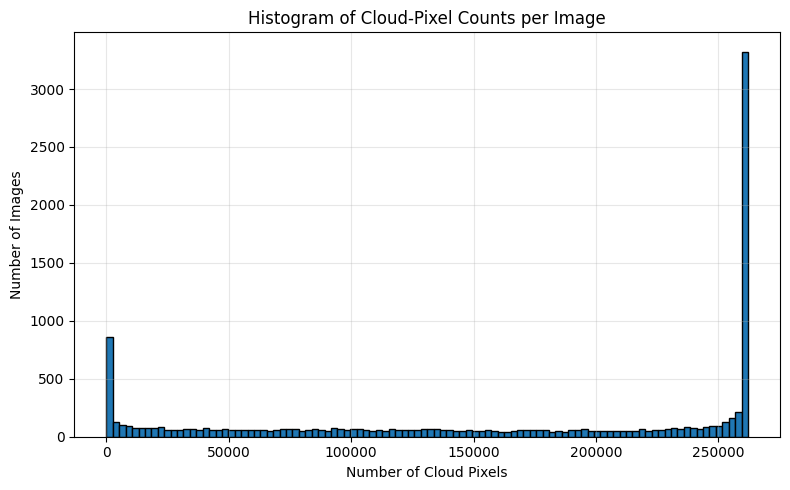

In [7]:
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.*')))
mask_paths  = sorted(glob.glob(os.path.join(mask_dir,  '*.*')))
assert len(image_paths) == len(mask_paths), "Images & masks counts must match"

cloud_counts = []
cloud_pct = []
total_pixels = 512 *512
# getting percentile of each image
for mp in mask_paths:
    mask = imread(mp)
    mask = (mask > 0).astype(np.uint8)
    cloud_counts.append(mask.sum())
    cloud_pct.append(mask.sum() / total_pixels * 100)

cloud_counts = np.array(cloud_counts)
cloud_pct = np.array(cloud_pct)


plt.figure(figsize=(8,5))
plt.hist(cloud_counts, bins=100, edgecolor='black')
plt.title('Histogram of Cloud-Pixel Counts per Image')
plt.xlabel('Number of Cloud Pixels')
plt.ylabel('Number of Images')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

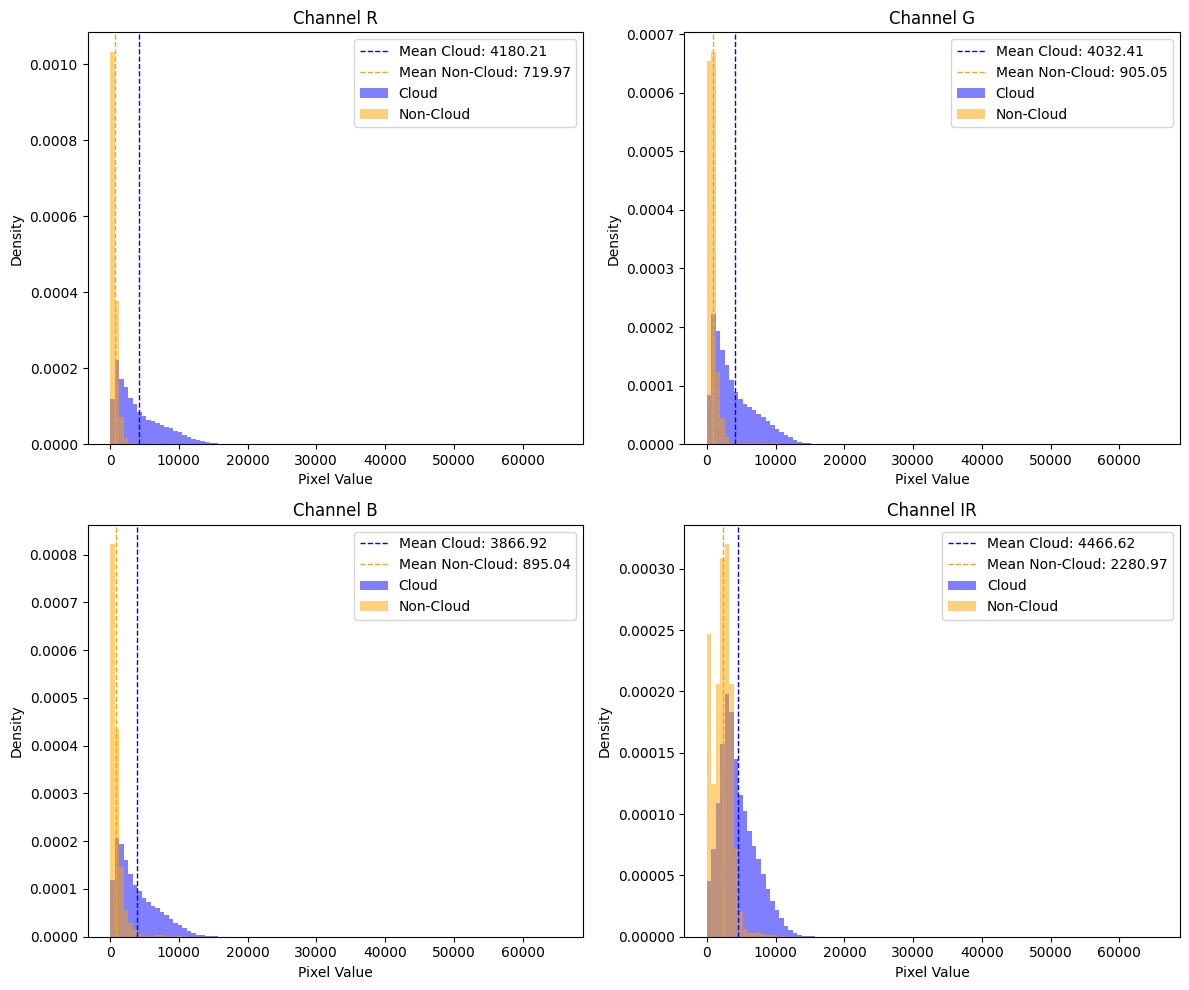

In [11]:
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt

sum_cloud = np.zeros(4, dtype=np.float64)
sum_non_cloud = np.zeros(4, dtype=np.float64)
count_cloud = np.zeros(4, dtype=np.int64)
count_non_cloud = np.zeros(4, dtype=np.int64)

bins = np.linspace(0, 2**16, 101)
bin_width = bins[1] - bins[0]
hist_cloud = [np.zeros(100, dtype=np.int64) for _ in range(4)]
hist_non_cloud = [np.zeros(100, dtype=np.int64) for _ in range(4)]

ip_i = 0
for ip, mp in zip(image_paths, mask_paths):
    if ip_i >= 1000:
        break
    ip_i += 1
    img = imread(ip)
    mask = imread(mp) 
    mask = (mask > 0).astype(np.uint8) 

    for i in range(4): 
        cloud_pix = img[:, :, i][mask == 1] 
        non_cloud_pix = img[:, :, i][mask == 0]
        sum_cloud[i] += np.sum(cloud_pix, dtype=np.float64)
        count_cloud[i] += len(cloud_pix)
        sum_non_cloud[i] += np.sum(non_cloud_pix, dtype=np.float64)
        count_non_cloud[i] += len(non_cloud_pix)
        hist_c, _ = np.histogram(cloud_pix, bins=bins)
        hist_cloud[i] += hist_c
        hist_nc, _ = np.histogram(non_cloud_pix, bins=bins)
        hist_non_cloud[i] += hist_nc
mean_cloud = sum_cloud / count_cloud
mean_non_cloud = sum_non_cloud / count_non_cloud


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
channel_names = ["R","G","B","IR"]
for i in range(4):
    ax = axes[i]
    bin_centers = (bins[:-1] + bins[1:]) / 2 
    total_cloud_pix = count_cloud[i]
    total_non_cloud_pix = count_non_cloud[i]
    density_cloud = hist_cloud[i] / (total_cloud_pix * bin_width) if total_cloud_pix > 0 else hist_cloud[i]
    density_non_cloud = hist_non_cloud[i] / (total_non_cloud_pix * bin_width) if total_non_cloud_pix > 0 else hist_non_cloud[i]
    ax.bar(bin_centers, density_cloud, width=bin_width, alpha=0.5, label='Cloud', color='blue')
    ax.bar(bin_centers, density_non_cloud, width=bin_width, alpha=0.5, label='Non-Cloud', color='orange')
    ax.axvline(mean_cloud[i], color='blue', linestyle='dashed', linewidth=1,
               label=f'Mean Cloud: {mean_cloud[i]:.2f}')
    ax.axvline(mean_non_cloud[i], color='orange', linestyle='dashed', linewidth=1,
               label=f'Mean Non-Cloud: {mean_non_cloud[i]:.2f}')
    ax.set_title(f'Channel {channel_names[i]}')
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
def normalize_rgb(img, p_lower=2, p_upper=98):
    rgb = img[..., :3].astype(float)
    out = np.zeros_like(rgb)
    for i in range(3):
        band = rgb[..., i]
        vmin, vmax = np.percentile(band, [p_lower, p_upper])
        out[..., i] = np.clip((band - vmin) / (vmax - vmin), 0, 1)
    return out

pctiles = [10, 50, 90, 100]
idxs = [np.argmin(np.abs(cloud_pct - p)) for p in pctiles]
n = len(idxs)
fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
for row, (p, idx) in enumerate(zip(pctiles, idxs)):
    img = imageio.imread(image_paths[idx])  # shape (H,W,4) or drop IR if you prefer
    mask = imageio.imread(mask_paths[idx])
    mask = (mask>0).astype(np.uint8)
    axes[row,0].imshow(normalize_rgb(img[...,:3]))
    axes[row,0].set_title(f'{p}th percentile image\ncloud pixels={cloud_counts[idx]} ({cloud_pct[idx]:.1f}%)')
    axes[row,0].axis('off')
    axes[row,1].imshow(mask, cmap='gray')
    axes[row,1].set_title('Cloud mask (1=cloud)')
    axes[row,1].axis('off')
plt.tight_layout()
plt.show()


# Now lets train the model

## Starting first with the deep learning model

In [3]:
!pip install segmentation-models-pytorch

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import pickle
from os.path import splitext
from os import listdir
import numpy as np
from glob import glob
import torch
from torch.utils.data import Dataset
import logging
from PIL import Image
import tifffile as tiff


import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch import Tensor
import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [15]:
class BasicDataset(Dataset):
    def __init__(self, imgs_dir, masks_dir, scale=1, mask_suffix=''):
        self.imgs_dir = imgs_dir
        self.masks_dir = masks_dir
        self.scale = scale
        assert 0 < scale <= 1, 'Scale must be between 0 and 1'

        self.ids = [splitext(file)[0] for file in listdir(imgs_dir)
                    if not file.startswith('.')]
        print(f'Creating dataset with {len(self.ids)} examples')

    def __len__(self):
        return len(self.ids)

    @classmethod
    def preprocess(cls, tif_img, scale):
        img_nd = np.array(tif_img)
        if len(img_nd.shape) == 2:
            img_nd = np.expand_dims(img_nd, axis=2)
        img_trans = img_nd.transpose((2, 0, 1))
        ################ if rgb only ################
        # img_trans = img_trans[:3,...]
        if img_trans.max() > 1:
            img_trans = img_trans / 65535
        return img_trans

    def __getitem__(self, i):
        idx = self.ids[i]
        mask_file = glob(self.masks_dir + idx + ".tif")
        img_file = glob(self.imgs_dir+idx+".tif")
        assert len(mask_file) == 1, \
            f'Either no mask or multiple masks found for the ID {idx}: {mask_file}'
        assert len(img_file) == 1, \
            f'Either no image or multiple images found for the ID {idx}: {img_file}'
        mask = tiff.imread(mask_file[0])
        img = tiff.imread(img_file[0])
        assert img.size/4 == mask.size, \
            f'Image and mask {idx} should be the same size, but are {img.shape} and {mask.shape}'
        img = self.preprocess(img, self.scale)
        mask = self.preprocess(mask, self.scale)

        return {
            'image': torch.from_numpy(img).type(torch.FloatTensor),
            'mask': torch.from_numpy(mask).type(torch.FloatTensor)
        }

In [5]:
def dice_loss(pred: Tensor, target: Tensor, epsilon: float = 1e-6):
    intersection = (pred * target).sum(dim=(2, 3))
    denom = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = 1 - (2 * intersection + 1) / (denom + 1)
    return dice.mean()


In [9]:
@torch.inference_mode()
def evaluate(net, dataloader, device):
    all_counts = [0] * (512*512+1)
    all_dices  = [0] * (512*512+1)

    net.eval()
    num_val_batches = len(dataloader)
    dice_score = 0
    # iterate over the validation set
    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=False):
        for batch in dataloader:
            image, mask_true = batch['image'], batch['mask']
            # move images and labels to correct device and type
            image = image.to(device=device)
            mask_true = mask_true.to(device=device)
            # predict the mask
            mask_pred = net(image)
            mask_pred = ((mask_pred) > 0.5).float()
            curr_dice_loss = dice_loss(mask_pred, mask_true)
            dice_score += curr_dice_loss
            count_white = int(mask_true.sum().item())
            all_counts[count_white]+=1
            all_dices[count_white]+=(curr_dice_loss.item())
    
    all_counts = np.array(all_counts)
    all_dices  = np.array(all_dices)
    all_dices/=len(dataloader)
    bin_width = 1000
    indices = np.arange(0, len(all_dices), bin_width)
    bin_sums = np.add.reduceat(all_dices, indices)
    bin_centers = indices + bin_width / 2
    plt.bar(bin_centers, bin_sums, width=bin_width, align='center', edgecolor='black')
    plt.xlabel('Number of Pixels (Binned)')
    plt.ylabel('Sum of Dice Losses')
    plt.title('Histogram of Sum of Dice Losses by Number of Pixels')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return 1- dice_score / len(dataloader)
    
# Loss combining dice and bce
class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        intersection = (pred * target).sum(dim=(2, 3))
        denom = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = 1 - (2 * intersection + 1) / (denom + 1)
        return bce + dice.mean()

In [10]:
dir_img = "/kaggle/input/cloud-masking-dataset/content/train/data/"
dir_mask = "/kaggle/input/cloud-masking-dataset/content/train/masks/"
img_scale = 1
val_percent = 0.2
batch_size = 10

In [16]:
dataset = BasicDataset(dir_img, dir_mask, img_scale)
n_val = int(len(dataset) * val_percent)
n_train = len(dataset) - n_val
train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))
loader_args = dict(batch_size=batch_size, num_workers=os.cpu_count(), pin_memory=True)
train_loader = DataLoader(train_set, batch_size=batch_size,num_workers=os.cpu_count(),pin_memory=True, shuffle=True)
val_loader = DataLoader(val_set, batch_size = 1, pin_memory=True,num_workers=os.cpu_count() ,shuffle=False, drop_last=True)

Creating dataset with 10573 examples


In [12]:
model = smp.DeepLabV3Plus(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    classes=1,
    activation='sigmoid'
)

# chaning the first layer
original_conv = model.encoder.conv1
new_conv = nn.Conv2d(
    4,
    original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=False
)
with torch.no_grad():
    new_conv.weight[:, :3, :, :] = original_conv.weight.clone()
    new_conv.weight[:, 3, :, :] = original_conv.weight.mean(dim=1)  # Initialize 4th channel
model.encoder.conv1 = new_conv
model = model.to(device)

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = CombinedLoss()

Epoch [1/10], Train Loss: 0.5221


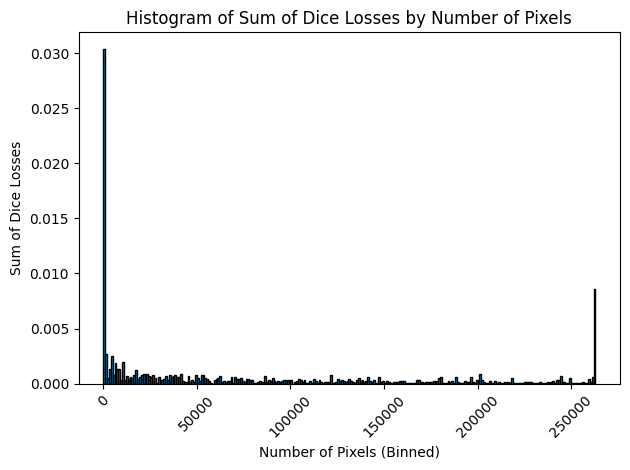

Validation Dice score: 0.8799569606781006
Checkpoint 0 saved!
Epoch [2/10], Train Loss: 0.4551


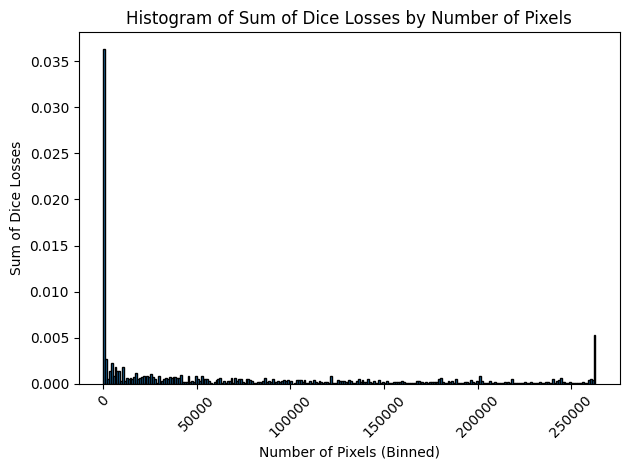

Validation Dice score: 0.8774732947349548
Checkpoint 1 saved!
Epoch [3/10], Train Loss: 0.4296


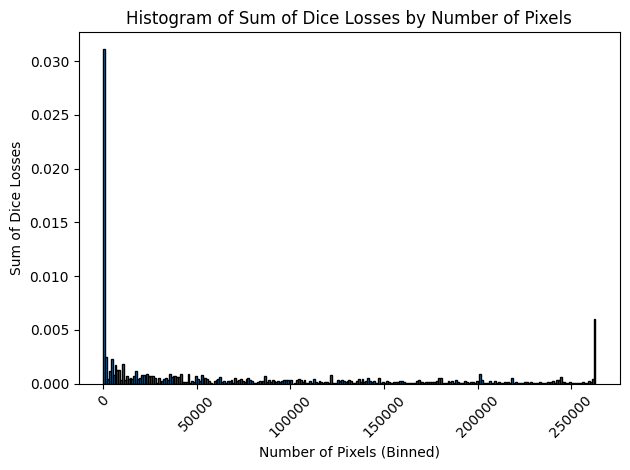

Validation Dice score: 0.8881173133850098
Checkpoint 2 saved!
Epoch [4/10], Train Loss: 0.4271


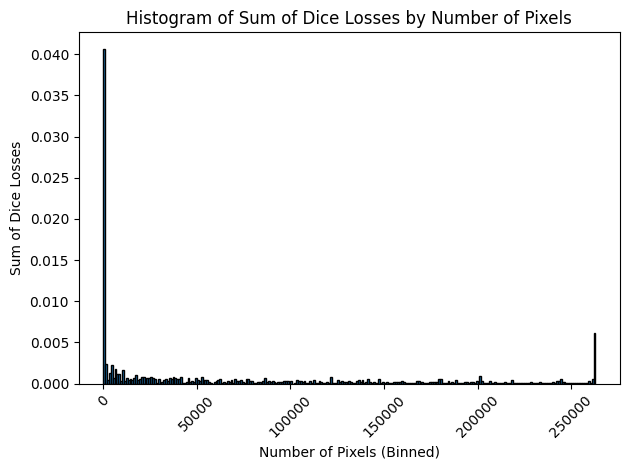

Validation Dice score: 0.8786118030548096
Checkpoint 3 saved!
Epoch [5/10], Train Loss: 0.4093


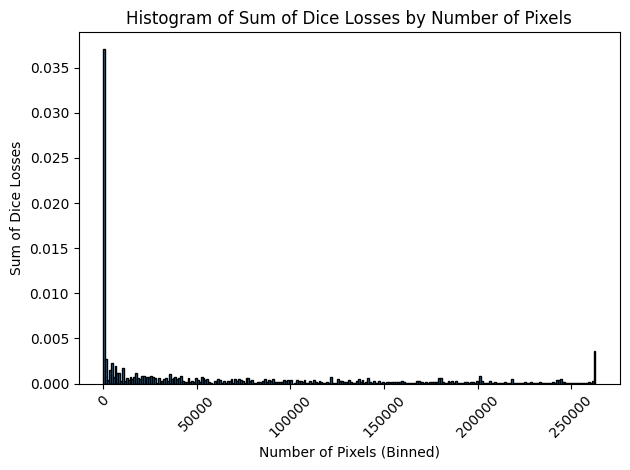

Validation Dice score: 0.8828336596488953
Checkpoint 4 saved!
Epoch [6/10], Train Loss: 0.4080


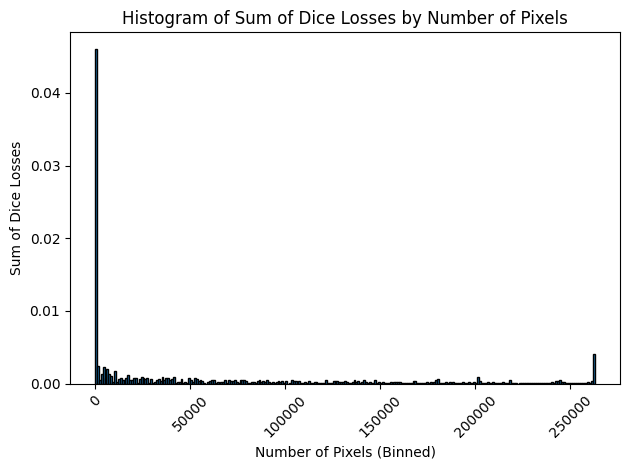

Validation Dice score: 0.8749405145645142
Checkpoint 5 saved!
Epoch [7/10], Train Loss: 0.4006


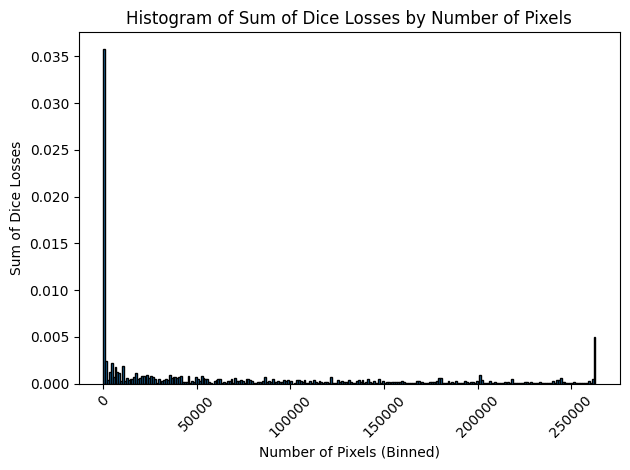

Validation Dice score: 0.884064793586731
Checkpoint 6 saved!
Epoch [8/10], Train Loss: 0.3960


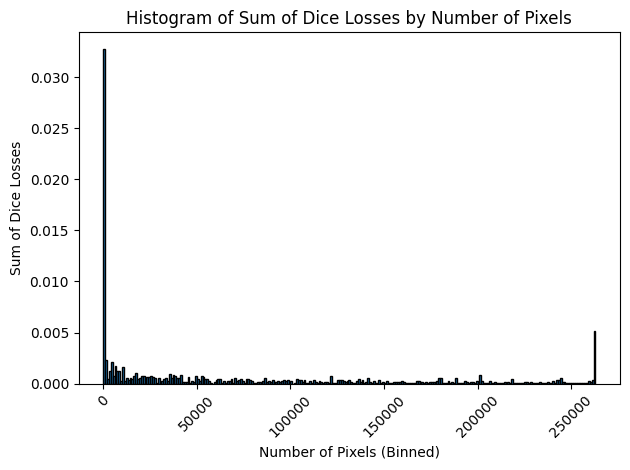

Validation Dice score: 0.8895283937454224
Checkpoint 7 saved!
Epoch [9/10], Train Loss: 0.3912


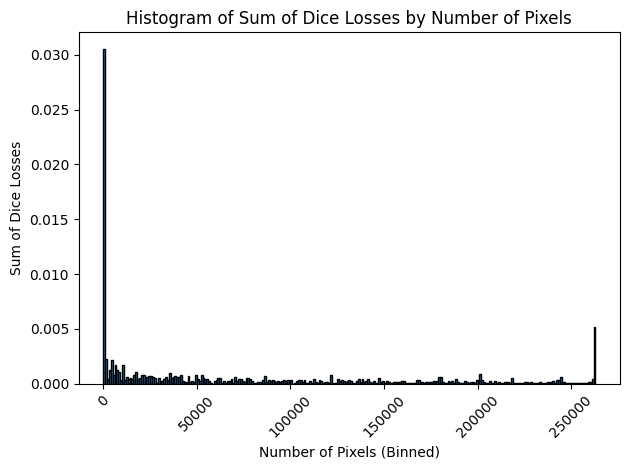

Validation Dice score: 0.890843391418457
Checkpoint 8 saved!
Epoch [10/10], Train Loss: 0.3833


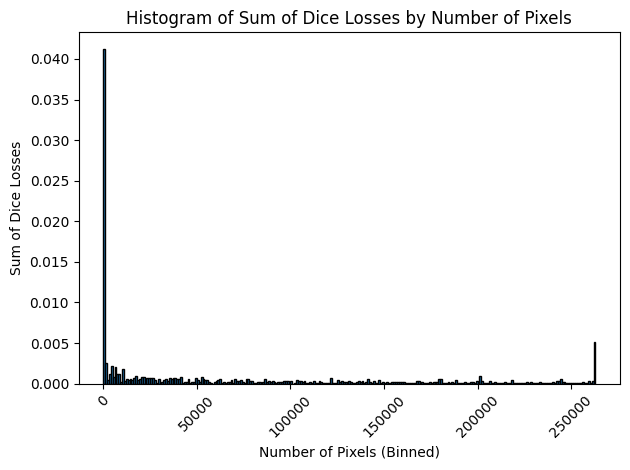

Validation Dice score: 0.8798916339874268
Checkpoint 9 saved!


In [17]:
train_loss_tot = []
val_score_tot = []
num_epochs = 10

best_model = None
best_dice_score = 0

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()   
    train_loss = running_loss / len(train_loader)
    train_loss_tot.append(train_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}')
    val_score = evaluate(model, val_loader, device)
    val_score_tot.append(val_score)
    if(val_score>best_dice_score): 
        best_model = model
        best_dice_score = val_score
    print('Validation Dice score: {}'.format(val_score))
    pickle.dump(model , open(f'model{epoch}.pk1' , 'wb'))
    print(f'Checkpoint {epoch} saved!')

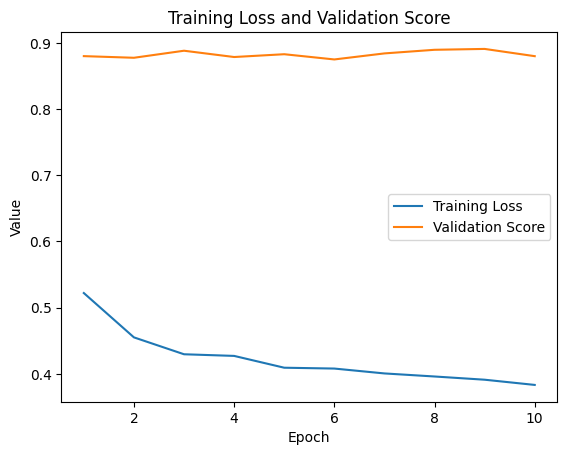

In [18]:
model = best_model

epochs = range(1, len(train_loss_tot) + 1)
val_score_tot=[t.item() for t in val_score_tot] 
plt.plot(epochs, train_loss_tot, label='Training Loss')
plt.plot(epochs, val_score_tot,   label='Validation Score')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Validation Score')
plt.legend()

plt.show()

In [19]:
def predict_img(net,
                full_img,
                device,
                scale_factor=1,
                out_threshold=0.5):
    net.eval()
    img = full_img
    img = img.unsqueeze(0)
    img = img.to(device=device)
    with torch.no_grad():
        mask = net(img)> out_threshold
    return mask[0].cpu().long().squeeze().numpy()

#dice loss for one image
def dice_loss_per_img(pred: Tensor, target: Tensor, epsilon: float = 1e-6):
    intersection = (pred * target).sum()
    denom = pred.sum() + target.sum()
    dice = 1 - (2 * intersection + 1) / (denom + 1)
    return dice.mean()

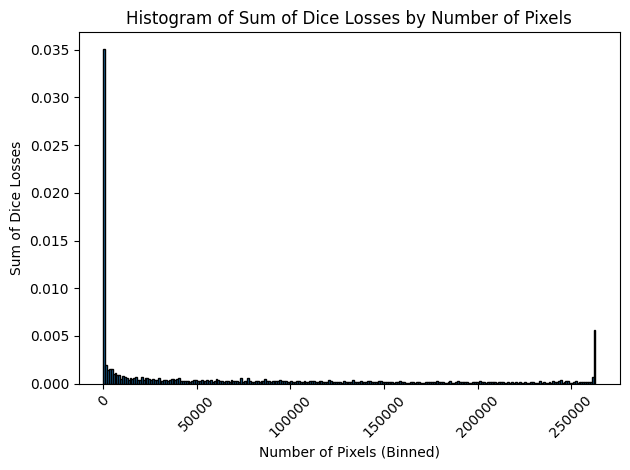

tensor(0.8897, device='cuda:0')

In [20]:
evaluate(model,DataLoader(dataset, batch_size=1,num_workers=os.cpu_count()),device)

## Classical model

Creating dataset with 10573 examples
Epoch  1  Train Loss: 0.6276   Val Loss: 0.6069   Val Dice: 0.7665
Epoch  2  Train Loss: 0.5857   Val Loss: 0.5718   Val Dice: 0.7665
Epoch  3  Train Loss: 0.5541   Val Loss: 0.5453   Val Dice: 0.7785
Epoch  4  Train Loss: 0.5304   Val Loss: 0.5256   Val Dice: 0.7963
Epoch  5  Train Loss: 0.5123   Val Loss: 0.5106   Val Dice: 0.8303
Epoch  6  Train Loss: 0.4985   Val Loss: 0.4993   Val Dice: 0.8368
Epoch  7  Train Loss: 0.4879   Val Loss: 0.4905   Val Dice: 0.8392
Epoch  8  Train Loss: 0.4794   Val Loss: 0.4837   Val Dice: 0.8387
Epoch  9  Train Loss: 0.4728   Val Loss: 0.4782   Val Dice: 0.8373
Epoch 10  Train Loss: 0.4674   Val Loss: 0.4737   Val Dice: 0.8372


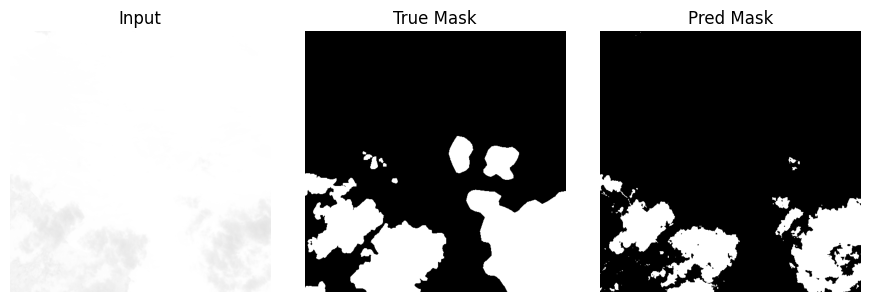

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

BATCH_SIZE = 4     
LR = 1e-3
EPOCHS = 10
VAL_SPLIT = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

full_ds = BasicDataset(dir_img, dir_mask)
n_val = int(len(full_ds) * VAL_SPLIT)
n_trn = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_trn, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


class PixelLogReg(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, 1)
    def forward(self, x):
        return self.linear(x)

sample = full_ds[0]['image']
C = sample.shape[0]
model     = PixelLogReg(C).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS+1):
    # --- Training ---
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        imgs = batch['image']
        msks = batch['mask']

        # flatten
        B, C_img, H, W = imgs.shape
        x = imgs.permute(0,2,3,1).reshape(-1, C_img).to(device)
        y = msks[:,0,...].reshape(-1,1).to(device)

        logits = model(x)
        loss   = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_trn = train_loss / len(train_loader)

    model.eval()
    val_loss     = 0.0
    dice_num     = 0.0
    dice_denom   = 0.0

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image']
            msks = batch['mask']
            B, C_img, H, W = imgs.shape
            x = imgs.permute(0,2,3,1).reshape(-1, C_img).to(device)
            y = msks[:,0,...].reshape(-1,1).to(device)
            logits = model(x)
            val_loss += criterion(logits, y).item()
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            dice_num   += 2 * (preds * y).sum().item()
            dice_denom += preds.sum().item() + y.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    dice_score   = dice_num / dice_denom if dice_denom > 0 else 0.0

    print(f"Epoch {epoch:2d}  Train Loss: {avg_trn:.4f}   Val Loss: {avg_val_loss:.4f}   Val Dice: {dice_score:.4f}")


model.eval()
with torch.no_grad():
    samp = val_ds[0]
    img = samp['image'].unsqueeze(0).to(device)   # (1,C,H,W)
    true_mask = samp['mask'][0].numpy()           # (H,W)

    B, C_img, H, W = img.shape
    feat = img.permute(0,2,3,1).reshape(-1, C_img)
    pred = (torch.sigmoid(model(feat)) > 0.5).cpu().numpy().reshape(H, W)

plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(img[0].permute(1,2,0).cpu());      plt.title("Input");      plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray');           plt.title("True Mask");  plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(pred, cmap='gray');                plt.title("Pred Mask");  plt.axis('off')
plt.tight_layout()
plt.show()

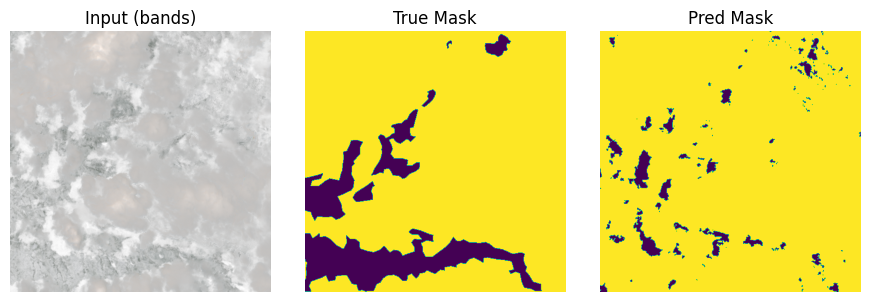

In [52]:
model.eval()
with torch.no_grad():
    sample = val_ds[3]
    img   = sample['image'].unsqueeze(0).to(device)
    img /=img.max()
    true  = sample['mask'][0].numpy()           
    B, C_img, H, W = img.shape
    feat  = img.permute(0,2,3,1).reshape(-1, C_img)
    pred  = torch.sigmoid(model(feat)).cpu().numpy().reshape(H, W) > 0.5

import matplotlib.pyplot as plt
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
rgb = img[0].permute(1,2,0).cpu()
rgb/=rgb.max()
plt.imshow(rgb); plt.title("Input (bands)"); plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(true,vmin=0,vmax=1); plt.title("True Mask"); plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(pred,vmin=0,vmax=1); plt.title("Pred Mask"); plt.axis('off')
plt.tight_layout()
plt.show()

In [51]:
pickle.dump(model , open(f'logistic_model.pk1' , 'wb'))
